Import Libraries

In [42]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Load Dataset

In [2]:
df = pd.read_csv((r"C:\Users\Rumeth\Downloads\fertilizer_recommendation.csv"))
df.head()  # displays the first 5 rows of the dataset

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


Features and Target Seperation

In [3]:
X = df.drop(columns=["Recommended_Fertilizer", "Season", "Region"])  # features for prediction
Y = df["Recommended_Fertilizer"]  # target variable for prediction

print("Features shape:", X.shape)  # prints the shape of the features
print("Target shape:", Y.shape)  # prints the shape of the target variable

Features shape: (10000, 17)
Target shape: (10000,)


Check Unique Classes

In [4]:
print("Number of unique fertilizers:", Y.nunique())  # prints the number of unique fertilizers in the target variable

print("\nUnique fertilizers and their counts:")  # prints the unique fertilizers and their counts
print(Y.value_counts())  # prints the counts of each unique fertilizer in the target variable

Number of unique fertilizers: 7

Unique fertilizers and their counts:
Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64


Dataset Split into Training and Testing

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(  
    X,      # Input features
    Y,      # Target variable
    test_size=0.2,  # Allocates 20% of the data for testing and 80% for training
    random_state=42,    # Ensures reproducibility of the split
    stratify=Y  # Maintains the class distribution in both sets
    )  

print("Training data:", X_train.shape) # Display the dimensions of the training dataset
print("Testing data:", X_test.shape) # Display the dimensions of the testing dataset

Training data: (8000, 17)
Testing data: (2000, 17)


Verify Class Distribution in Testing and Training Sets

In [6]:
print("Training target distribution:")
print(Y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(Y_test.value_counts(normalize=True).round(3))

Training target distribution:
Recommended_Fertilizer
Urea             0.310
DAP              0.292
MOP              0.141
Compost          0.100
Zinc Sulphate    0.075
NPK              0.064
SSP              0.018
Name: proportion, dtype: float64

Testing target distribution:
Recommended_Fertilizer
Urea             0.310
DAP              0.292
MOP              0.141
Compost          0.100
Zinc Sulphate    0.075
NPK              0.064
SSP              0.018
Name: proportion, dtype: float64


Create Preprocessing Pipeline

In [8]:
# Seperating numerical and categorical features 
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["str"]
).columns.tolist()

Numeric Pipeline

In [11]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median") # handles missing values by replacing them with the median of the column
        ),
        (
            "scaler",
            StandardScaler() # standardizes features by removing the mean and scaling to unit variance
        )
    ]
)

Categorical Pipeline

In [12]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",  # fills missing values with a constant value
                fill_value="Unknown"  # fills missing values with the string "Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore" # ignores any unknown categories encountered during transformation
            )
        )
    ]
)

Combined Preprocessor

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features  # applies the numeric_transformer to the numerical features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features  # applies the categorical_transformer to the categorical features
        )
    ]
) 

Preprocessing the Training and Testing Data

In [15]:
X_train_preprocessed = preprocessor.fit_transform(X_train)  # fits the preprocessor to the training data and transforms it
X_test_preprocessed = preprocessor.transform(X_test)  # transforms the testing data using the fitted preprocessor

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_preprocessed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_preprocessed.shape)

Original training shape: (8000, 17)
Processed training shape: (8000, 38)

Original testing shape: (2000, 17)
Processed testing shape: (2000, 38)


Encode Target Labels

In [17]:
label_encoder = LabelEncoder()

Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

label_mapping = {   # creates a mapping of the encoded labels to their original string labels
    label: index
    for index, label in enumerate(label_encoder.classes_)
}

print(label_mapping)

{'Compost': 0, 'DAP': 1, 'MOP': 2, 'NPK': 3, 'SSP': 4, 'Urea': 5, 'Zinc Sulphate': 6}


In [18]:
print("X_train_processed:", X_train_preprocessed.shape)
print("X_test_processed:", X_test_preprocessed.shape)

print("Y_train_encoded:", Y_train_encoded.shape)
print("Y_test_encoded:", Y_test_encoded.shape)

X_train_processed: (8000, 38)
X_test_processed: (2000, 38)
Y_train_encoded: (8000,)
Y_test_encoded: (2000,)


In [19]:
feature_names = preprocessor.get_feature_names_out()  # retrieves the names of the features after preprocessing

print ("Number of preprocessed features:", len(feature_names))  # prints the number of preprocessed features
print("\nFirst 20 Features: ")
print(feature_names[:20])  # prints the first 20 feature names after preprocessing

Number of preprocessed features: 38

First 20 Features: 
['num__Soil_pH' 'num__Soil_Moisture' 'num__Organic_Carbon'
 'num__Electrical_Conductivity' 'num__Nitrogen_Level'
 'num__Phosphorus_Level' 'num__Potassium_Level' 'num__Temperature'
 'num__Humidity' 'num__Rainfall' 'num__Fertilizer_Used_Last_Season'
 'num__Yield_Last_Season' 'cat__Soil_Type_Clay' 'cat__Soil_Type_Loamy'
 'cat__Soil_Type_Sandy' 'cat__Soil_Type_Silt' 'cat__Crop_Type_Cotton'
 'cat__Crop_Type_Maize' 'cat__Crop_Type_Potato' 'cat__Crop_Type_Rice']


Convert Preprocessed Data to DataFrames

In [20]:
X_train_processed_df = pd.DataFrame(
    X_train_preprocessed,  # creates a DataFrame from the preprocessed training data
    columns=feature_names,  # assigns the feature names as column headers for the DataFrame
    index=X_train.index  # assigns the original index of the training data to the DataFrame
)

X_test_processed_df = pd.DataFrame(
    X_test_preprocessed,    # creates a DataFrame from the preprocessed test data
    columns=feature_names,  # assigns the feature names as column headers for the DataFrame
    index=X_test.index  # assigns the original index of the test data to the DataFrame
)

X_train_processed_df.head()

,num__Soil_pH,num__Soil_Moisture,num__Organic_Carbon,num__Electrical_Conductivity,num__Nitrogen_Level,num__Phosphorus_Level,num__Potassium_Level,num__Temperature,num__Humidity,num__Rainfall,...,cat__Irrigation_Type_Drip,cat__Irrigation_Type_Rainfed,cat__Irrigation_Type_Sprinkler,cat__Previous_Crop_Cotton,cat__Previous_Crop_Maize,cat__Previous_Crop_Potato,cat__Previous_Crop_Rice,cat__Previous_Crop_Sugarcane,cat__Previous_Crop_Tomato,cat__Previous_Crop_Wheat
9497,-0.184123,1.594732,1.041974,0.457637,-0.813498,0.125873,-0.470426,1.111746,-1.262523,-1.285614,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1229,-0.374158,1.086289,-1.505230,-1.556179,0.254867,-1.549997,0.630400,-0.423554,-0.527011,-0.929895,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4168,-0.788779,-1.528065,-0.593599,1.144703,-0.888036,-0.475721,-1.413992,-0.257858,-1.641476,-0.808610,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8971,0.161395,0.084663,-1.263916,-0.158354,-1.434641,-0.475721,-1.130922,-0.810566,-0.157819,0.504572,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6074,-0.685124,-0.922512,0.183968,0.279947,-0.142664,-0.819490,-1.099470,-1.729429,1.260382,0.617745,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Saving the Preprocessor and Label Encoder

In [ ]:
joblib.dump(
    preprocessor,       
    "preprocessor.pkl"  
)

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Preprocessor and label encoder saved successfully.")

Preprocessor and label encoder saved successfully.


Feature Engineering

In [24]:
# Create copies of the orginal sets

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()


# Total NPK

X_train_fe["Total_NPK"] = (
    X_train_fe["Nitrogen_Level"] + X_train_fe["Phosphorus_Level"] + X_train_fe["Potassium_Level"]
)

X_test_fe["Total_NPK"] = (
    X_test_fe["Nitrogen_Level"] + X_test_fe["Phosphorus_Level"] + X_test_fe["Potassium_Level"]
)


# NPK Ratios

X_train_fe["N_to_P_Ratio"] = (
    X_train_fe["Nitrogen_Level"] / (X_train_fe["Phosphorus_Level"] + 1)
)
 
X_test_fe["N_to_P_Ratio"] = (
    X_test_fe["Nitrogen_Level"] / (X_test_fe["Phosphorus_Level"] + 1)
)

X_train_fe["N_to_K_Ratio"] = (
    X_train_fe["Nitrogen_Level"] / (X_train_fe["Potassium_Level"] + 1)
)

X_test_fe["N_to_K_Ratio"] = (
    X_test_fe["Nitrogen_Level"] / (X_test_fe["Potassium_Level"] + 1)
)

X_train_fe["P_to_K_Ratio"] = (
    X_train_fe["Phosphorus_Level"] / (X_train_fe["Potassium_Level"] + 1)
)

X_test_fe["P_to_K_Ratio"] = (
    X_test_fe["Phosphorus_Level"] / (X_test_fe["Potassium_Level"] + 1)
)


# NPK Balance

npk_columns = ["Nitrogen_Level", "Phosphorus_Level", "Potassium_Level"]

X_train_fe["NPK_Std"] = X_train_fe[npk_columns].std(axis=1)

X_test_fe["NPK_Std"] = X_test_fe[npk_columns].std(axis=1)


# Soil pH Category

def classify_soil_ph(ph):

    if ph < 5.5:
        return "Acidic"

    elif ph <= 7.5:
        return "Neutral"

    else:
        return "Alkaline"


X_train_fe["Soil_pH_Category"] = X_train_fe["Soil_pH"].apply(classify_soil_ph)

X_test_fe["Soil_pH_Category"] = X_test_fe["Soil_pH"].apply(classify_soil_ph)


# Temperature-Humidity Interaction

X_train_fe["Temp_Humidity_Interaction"] = (
    X_train_fe["Temperature"] * X_train_fe["Humidity"]
)

X_test_fe["Temp_Humidity_Interaction"] = (
    X_test_fe["Temperature"] * X_test_fe["Humidity"]
)


# Rainfall-Soil Moisture Interaction

X_train_fe["Rainfall_Soil_Moisture_Interaction"] = (
    X_train_fe["Rainfall"] * X_train_fe["Soil_Moisture"]
)

X_test_fe["Rainfall_Soil_Moisture_Interaction"] = (
    X_test_fe["Rainfall"] * X_test_fe["Soil_Moisture"]
)

Identify New Feature Types

In [25]:
numerical_features_fe = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features_fe = X_train_fe.select_dtypes(include=["str"]).columns.tolist()

Create New Preprocessor

In [26]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features_fe
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features_fe
        )
    ]
)

In [27]:
# Process training data
X_train_fe_processed = preprocessor_fe.fit_transform(X_train_fe) 

# Process testing data
X_test_fe_processed = preprocessor_fe.transform(X_test_fe)

print("Feature Engineering Completed")

print("Original features:",X_train.shape[1])

print("Features after engineering:",X_train_fe.shape[1])

print("Processed features:",X_train_fe_processed.shape[1])

print("\nNew Features:")

new_features = [
    "Total_NPK",
    "N_to_P_Ratio",
    "N_to_K_Ratio",
    "P_to_K_Ratio",
    "NPK_Std",
    "Soil_pH_Category",
    "Temp_Humidity_Interaction",
    "Rainfall_Soil_Moisture_Interaction"
]

for feature in new_features:
    print("-", feature)

Feature Engineering Completed
Original features: 17
Features after engineering: 25
Processed features: 48

New Features:
- Total_NPK
- N_to_P_Ratio
- N_to_K_Ratio
- P_to_K_Ratio
- NPK_Std
- Soil_pH_Category
- Temp_Humidity_Interaction
- Rainfall_Soil_Moisture_Interaction


Model Evaluation

In [29]:
# Dictionary to store evaluation results for each model
results = {}

def evaluate_model(model, X_train, Y_train, X_test, Y_test, model_name):

    # Train model
    model.fit(X_train, Y_train)

    # Make predictions
    Y_pred = model.predict(X_test)

    # Calculate the accuracy
    accuracy = accuracy_score(Y_test, Y_pred)

    # Calculate macro-average precision across all classes
    precision = precision_score(
        Y_test,    
        Y_pred,
        average="macro",  
        zero_division=0
    )

    # Calculate macro-average recall across all classes
    recall = recall_score(
        Y_test,
        Y_pred,
        average="macro",
        zero_division=0
    )

    # Calculate macro-average F1 score across all classes
    f1 = f1_score(
        Y_test,
        Y_pred,
        average="macro",
        zero_division=0
    )

    # Store results
    results[model_name] = {
        "Accuracy": accuracy,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1 Score (Macro)": f1
    }

    # Print results
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")

    return model, Y_pred

Logistic Regresssion Model

In [31]:
logistic_model = LogisticRegression(max_iter = 2000, random_state = 42)

logistic_model, logistic_predictions = evaluate_model(
    logistic_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "Logistic Regression"
)

Logistic Regression
Accuracy: 0.8090
Precision (Macro): 0.6829
Recall (Macro): 0.6716
F1 Score (Macro): 0.6745


Decision Tree Model

In [ ]:
decision_tree_model = DecisionTreeClassifier(
    random_state = 42
)

decision_tree_model, decision_tree_predictions = evaluate_model(
    decision_tree_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "Decision Tree"
)

Decision Tree
Accuracy: 0.8775
Precision (Macro): 0.7405
Recall (Macro): 0.7442
F1 Score (Macro): 0.7420


Random Forest Model

In [36]:
random_forest_model = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    class_weight="balanced",
    n_jobs = -1
)

random_forest_model, random_forest_predictions = evaluate_model(
    random_forest_model,
    X_train_fe_processed,
    Y_train_encoded,
    X_test_fe_processed,
    Y_test_encoded,
    "Random Forest"
)

Random Forest
Accuracy: 0.8720
Precision (Macro): 0.7302
Recall (Macro): 0.7601
F1 Score (Macro): 0.7386


Summary of Results

In [37]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Logistic Regression,0.8090,0.682947,0.671559,0.674546
Decision Tree,0.8775,0.740510,0.744189,0.742039
Random Forest,0.8720,0.730194,0.760096,0.738605


Sort by F1 Score

In [38]:
results_df = results_df.sort_values(
    by="F1 Score (Macro)",
    ascending=False
)

results_df

,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Decision Tree,0.8775,0.740510,0.744189,0.742039
Random Forest,0.8720,0.730194,0.760096,0.738605
Logistic Regression,0.8090,0.682947,0.671559,0.674546


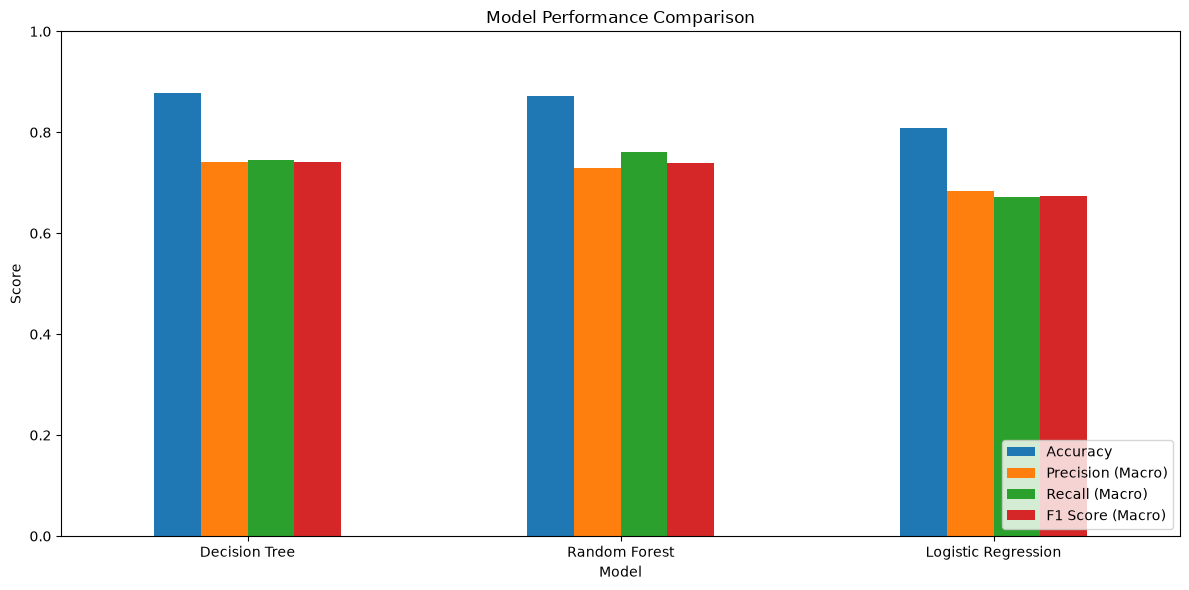

In [ ]:
# Plot the model performance results as a bar chart
results_df.plot(
    kind = "bar",
    figsize = (12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)  # Keep the model names horizontal

plt.ylim(0, 1)  # Set the y axis range from 0 to 1

plt.legend(     # Display the legend in the lower right corner
    loc="lower right"
)

plt.tight_layout()
plt.show()

Confusion Matrix for Random Forest Model Predictions

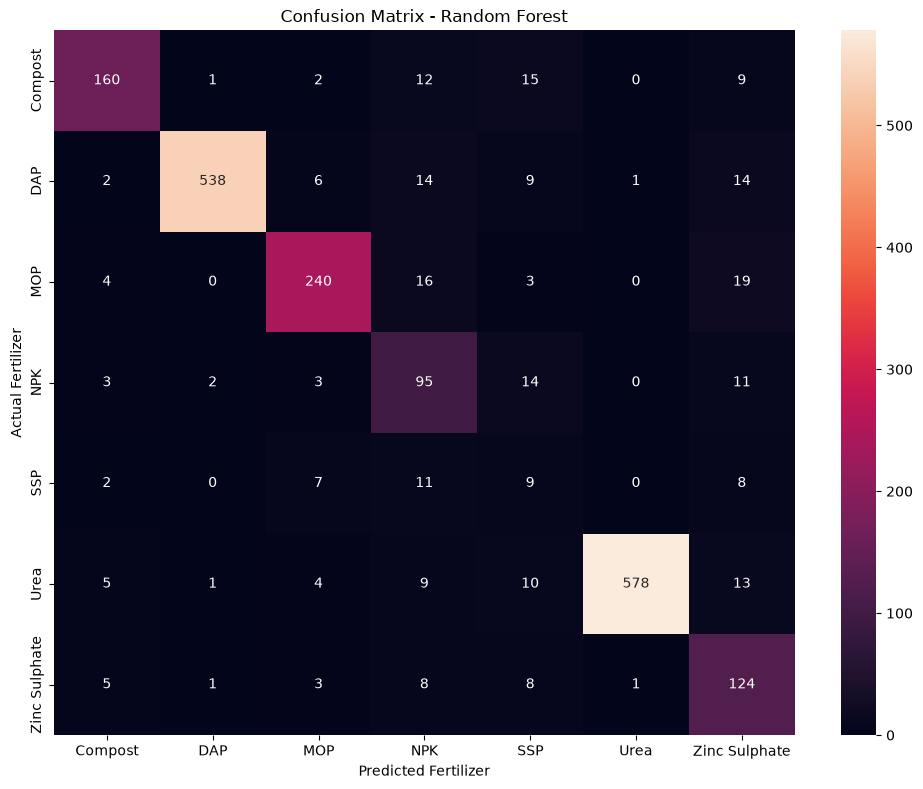

In [ ]:
# Calculate the confusion matrix using the actual and predicted labels
cm = confusion_matrix(
    Y_test_encoded,
    random_forest_predictions
)

plt.figure(figsize=(10, 8))     # Create a figure for the confusion matrix

sns.heatmap(    # Display the confusion matrix as a heatmap
    cm,
    annot=True,     # Display the values inside each cell
    fmt="d",    # Format the values as integers
    xticklabels=label_encoder.classes_,     # Labels for predicted classes
    yticklabels=label_encoder.classes_  # Labels for actual classes
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")

plt.tight_layout()
plt.show()

Feature Importance

In [ ]:
# Get the feature names after preprocessing and feature engineering
feature_names_fe = preprocessor_fe.get_feature_names_out()

# Create a DataFrame containing each feature and its importance score
feature_importance = pd.DataFrame({
    "Feature": feature_names_fe,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,num__Nitrogen_Level,0.114963
5,num__Phosphorus_Level,0.099890
0,num__Soil_pH,0.093032
13,num__N_to_P_Ratio,0.072319
6,num__Potassium_Level,0.070647
14,num__N_to_K_Ratio,0.061010
15,num__P_to_K_Ratio,0.060969
12,num__Total_NPK,0.047544
33,cat__Crop_Growth_Stage_Vegetative,0.044557
45,cat__Soil_pH_Category_Acidic,0.043501


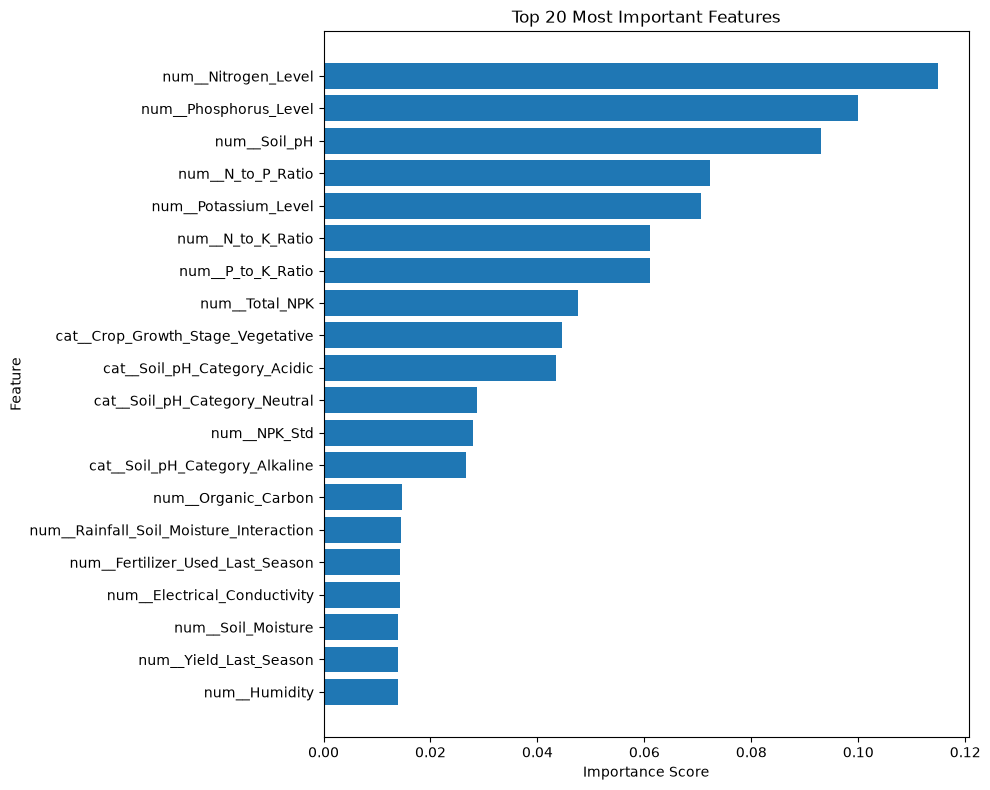

In [ ]:
# Select the top 20 most important features
top_features = feature_importance.head(20)

# Create the figure and set its size
plt.figure(figsize=(10, 8))

# Create a horizontal bar chart
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

# Add labels to the x axis and y axis
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# chart title
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()   # Invert the y axis (the most important feature appears at the top)

plt.tight_layout()  # Adjust the layout to prevent labels from being cut off
plt.show()